# Mailing statistics for CPL (recommendation models testing) 

In [1]:
import os
import sys

CURRENT_DIR = os.path.abspath("")

# add parent dir to python path
sys.path.append(os.path.join(CURRENT_DIR, ".."))

In [2]:
import pandas as pd

from src.v2.db_utils import execute_query

MAILS_QUERY = """
select
	date(p.scheduled_at),
	sum(case when p.communication_status = 'leaded' then 1 else 0 end) as leaded_cnt,
	sum(case when p.communication_status in ('open', 'click', 'leaded') then 1 else 0 end) as opened_cnt,
	sum(case when p.communication_status not in
        ('waiting', 'skipped', 'sending', 'proxy_err', 'param_err', 'err_null_score') then 1 else 0 end) as total_cnt,
	sum(case when p.communication_status = 'leaded' then COALESCE(bp.lead_price, 0) else 0 end) as leaded_price
from
	emails_ai.prospect p
left join rds2.offers_budget b on p.offer_id = b.offer_id
left join rds2.offers_budgetperiod bp on
	b.id = bp.budget_id and
	DATE_TRUNC('month', p.scheduled_at) = bp.period
where
	p.scheduled_at >= %s
    and p.scheduled_at < %s
    and bp.settlement = 0
    and p.sg_message_id is not null
group by
	date(p.scheduled_at)
"""


async def load_mailing_stats(start_date: str, end_date: str) -> pd.DataFrame:
    mailing_stats_data = await execute_query(MAILS_QUERY, (start_date, end_date))
    return pd.DataFrame(mailing_stats_data)

In [3]:
# mailing_stats_df = await load_mailing_stats("2025-04-12", "2025-05-24")
mailing_stats_df = await load_mailing_stats("2025-05-07", "2025-07-31")

In [4]:
mailing_stats_df

,date,leaded_cnt,opened_cnt,total_cnt,leaded_price
0,2025-05-07,82,6154,17321,7540
1,2025-05-08,120,10369,36792,10957
2,2025-05-09,100,4539,13603,9093
3,2025-05-10,124,7553,27638,11359
4,2025-05-11,70,5353,16913,6419
...,...,...,...,...,...
60,2025-07-09,56,5300,20571,5236
61,2025-07-10,127,8301,24551,11566
62,2025-07-11,22,1039,3641,2098
63,2025-07-14,152,12435,42957,13052


In [5]:
mailing_stats_df["lead_rate"] = (mailing_stats_df["leaded_cnt"] / mailing_stats_df["opened_cnt"]).fillna(0) * 100
mailing_stats_df["open_rate"] = (mailing_stats_df["opened_cnt"] / mailing_stats_df["total_cnt"]).fillna(0) * 100
mailing_stats_df["click_rate"] = (
    (mailing_stats_df["opened_cnt"] - mailing_stats_df["leaded_cnt"]) / mailing_stats_df["total_cnt"]
).fillna(0) * 100
mailing_stats_df["leaded_price_normalized"] = (
    mailing_stats_df["leaded_price"] / mailing_stats_df["leaded_cnt"]
).fillna(0)
mailing_stats_df["leaded_price_by_total_cnt"] = (
    mailing_stats_df["leaded_price"] / mailing_stats_df["total_cnt"]
).fillna(0)

In [6]:
# label dates with models used for scoring
model_dates = {
    # "2025-04-16": "AutoEncoder",
    # "2025-04-18": "AutoEncoder",
    # "2025-04-20": "AutoEncoder",
    # "2025-04-22": "AutoEncoder",
    # "2025-04-23": "KNN",
    # "2025-04-24": "KNN",
    # "2025-04-25": "KNN",
    "2025-05-06": "KNN",
    "2025-05-09": "AutoEncoder",
    "2025-05-10": "KNN",
    "2025-05-12": "AutoEncoder",
    "2025-05-13": "KNN",
    "2025-05-15": "AutoEncoder",
    "2025-05-16": "KNN",
    "2025-05-18": "AutoEncoder",
    "2025-05-19": "KNN",
    "2025-05-21": "AutoEncoder",
    "2025-05-22": "KNN",
    "2025-05-24": "AutoEncoder",
    "2025-05-25": "KNN",
    "2025-05-27": "AutoEncoder",
    "2025-05-28": "KNN",
    "2025-05-30": "AutoEncoder",
    "2025-05-31": "KNN",
    "2025-06-02": "AutoEncoder",
    "2025-06-03": "KNN",
    "2025-06-05": "AutoEncoder",
    "2025-06-06": "KNN",
    "2025-06-08": "AutoEncoder",
    "2025-06-09": "KNN",
    "2025-06-11": "AutoEncoder",
    "2025-06-12": "KNN",
    "2025-06-14": "AutoEncoder",
    "2025-06-15": "KNN",
    "2025-06-17": "AutoEncoder",
    "2025-06-18": "KNN",
    "2025-06-20": "AutoEncoder",
    "2025-06-21": "KNN",
    "2025-06-23": "AutoEncoder",
    "2025-06-24": "KNN",
    "2025-06-26": "AutoEncoder",
    "2025-06-27": "KNN",
    "2025-06-29": "AutoEncoder",
    "2025-06-30": "KNN",
    "2025-07-02": "AutoEncoder",
    "2025-07-03": "KNN",
    "2025-07-05": "AutoEncoder",
    "2025-07-06": "KNN",
    "2025-07-08": "AutoEncoder",
    "2025-07-09": "KNN",
    "2025-07-11": "AutoEncoder",
    "2025-07-12": "KNN",
    "2025-07-14": "AutoEncoder",
    "2025-07-15": "KNN",
    "2025-07-17": "AutoEncoder",
    "2025-07-18": "KNN",
    "2025-07-20": "AutoEncoder",
    "2025-07-21": "KNN",
}

# Use 'Base' as the default value when a date doesn't have a specific model assigned
mailing_stats_df["model"] = mailing_stats_df["date"].apply(lambda x: model_dates.get(x.strftime("%Y-%m-%d"), "Base"))

In [7]:
mailing_stats_df

,date,leaded_cnt,opened_cnt,total_cnt,leaded_price,lead_rate,open_rate,click_rate,leaded_price_normalized,leaded_price_by_total_cnt,model
0,2025-05-07,82,6154,17321,7540,1.332467,35.529126,35.055713,91.951220,0.435310,Base
1,2025-05-08,120,10369,36792,10957,1.157296,28.182757,27.856599,91.308333,0.297809,Base
2,2025-05-09,100,4539,13603,9093,2.203128,33.367639,32.632508,90.930000,0.668455,AutoEncoder
3,2025-05-10,124,7553,27638,11359,1.641732,27.328316,26.879658,91.604839,0.410992,KNN
4,2025-05-11,70,5353,16913,6419,1.307678,31.650210,31.236327,91.700000,0.379531,Base
...,...,...,...,...,...,...,...,...,...,...,...
60,2025-07-09,56,5300,20571,5236,1.056604,25.764426,25.492198,93.500000,0.254533,KNN
61,2025-07-10,127,8301,24551,11566,1.529936,33.811250,33.293960,91.070866,0.471101,Base
62,2025-07-11,22,1039,3641,2098,2.117421,28.536116,27.931887,95.363636,0.576215,AutoEncoder
63,2025-07-14,152,12435,42957,13052,1.222356,28.947552,28.593710,85.868421,0.303839,AutoEncoder


In [8]:
# fill 2025-04-11 with mean for Base model
# mailing_stats_df.loc[mailing_stats_df["date"].astype(str) == "2025-04-11", ["lead_rate", "open_rate", "click_rate"]] = (
#     mailing_stats_df[(mailing_stats_df["model"] == "Base") & (mailing_stats_df["date"].astype(str) != "2025-04-11")][
#         ["lead_rate", "open_rate", "click_rate"]
#     ].mean().values
# )

In [9]:
# calculate correlation between lead_rate and total_cnt
correlation = mailing_stats_df["lead_rate"].corr(mailing_stats_df["total_cnt"])
print(f"Correlation between lead_rate and total_cnt: {correlation:.4f}")
# interpretation:
# A positive correlation indicates that as the total number of emails sent increases, the lead rate also
# tends to increase, suggesting that more emails lead to more leads.

Correlation between lead_rate and total_cnt: -0.5428


In [10]:
# mailing_stats_df

In [11]:
# create plots with seaborn
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import seaborn as sns


def plot_mailing_stats_by_model(mailing_stats_df: pd.DataFrame, window_size: int = 3) -> None:
    # Set the style for all plots
    sns.set(style="whitegrid")

    # Create a figure with three subplots arranged vertically
    fig, axes = plt.subplots(6, 1, figsize=(12, 34))

    # Colors and markers for each model type
    model_styles = {
        "Base": {"color": "#1f77b4", "marker": "o", "markersize": 10},
        "AutoEncoder": {"color": "#ff7f0e", "marker": "D", "markersize": 12},
        "KNN": {"color": "#2ca02c", "marker": "s", "markersize": 10},
    }

    # Line styles for raw vs smoothed data
    raw_line_style = {"linewidth": 2, "alpha": 1}
    smoothed_line_style = {"linewidth": 1, "linestyle": "--", "alpha": 0.8}

    titles = {
        "open_rate": "Open Rate",
        "click_rate": "Click Rate",
        "lead_rate": "Lead Rate",
        "leaded_price": "Total Lead Price",
        "leaded_price_normalized": "Lead Price Normalized",
        "leaded_price_by_total_cnt": "Lead Price by Total Count",
    }

    # Make sure date column is properly datetime type
    if not pd.api.types.is_datetime64_any_dtype(mailing_stats_df["date"]):
        mailing_stats_df = mailing_stats_df.copy()
        mailing_stats_df["date"] = pd.to_datetime(mailing_stats_df["date"])

    # Sort dataframe by date to ensure proper line plotting
    mailing_stats_df = mailing_stats_df.sort_values("date")

    # Plot each metric in its own subplot
    for i, metric in enumerate(["open_rate", "click_rate", "lead_rate", "leaded_price", "leaded_price_normalized", "leaded_price_by_total_cnt"]):
        ax = axes[i]

        # Plot for each model type separately
        for model_name, group_df in mailing_stats_df.groupby("model"):
            style = model_styles[model_name]

            # Skip if there are too few data points for this model
            if len(group_df) < 2:
                continue

            # Plot the original/raw data
            sns.lineplot(
                data=group_df,
                x="date",
                y=metric,
                ax=ax,
                marker=style["marker"],
                markersize=style["markersize"],
                color=style["color"],
                **raw_line_style,
                label=f"{model_name} (Raw)",
            )

            # Calculate the smoothed data using rolling average if enough data points are available
            if len(group_df) >= window_size:
                # Create a temporary dataframe sorted by date
                temp_df = group_df.sort_values("date").copy()
                # Calculate the rolling average
                temp_df[f"{metric}_smoothed"] = temp_df[metric].rolling(window=window_size, min_periods=1).mean()

                # Plot the smoothed line without markers
                sns.lineplot(
                    data=temp_df,
                    x="date",
                    y=f"{metric}_smoothed",
                    ax=ax,
                    color=style["color"],
                    **smoothed_line_style,
                    label=f"{model_name} (Smoothed)",
                )

            # Add value annotations to raw data points
            for _, row in group_df.iterrows():
                date = row["date"]
                value = row[metric]
                if metric in ["open_rate", "click_rate", "lead_rate"]:
                    ax.annotate(
                        f"{value:.2f}%",
                        (date, value),
                        textcoords="offset points",
                        xytext=(0, 10),
                        ha="center",
                        fontsize=9,
                        fontweight="bold",
                        color=style["color"],
                    )
                else:
                    ax.annotate(
                        f"{value:.2f}",
                        (date, value),
                        textcoords="offset points",
                        xytext=(0, 10),
                        ha="center",
                        fontsize=9,
                        fontweight="bold",
                        color=style["color"],
                    )

        # Set title and labels
        ax.set_title(f"{titles[metric]} by Model Type", fontsize=16)
        ax.set_xlabel("Date", fontsize=12)
        ax.set_ylabel(f"{titles[metric]} (%)", fontsize=12)

        # Format x-axis with dates
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
        plt.setp(ax.get_xticklabels(), rotation=45)

        # Add legend with larger markers
        ax.legend(title="Model Type", fontsize=12, title_fontsize=14)

    plt.tight_layout()
    plt.subplots_adjust(hspace=0.3)  # Add more space between subplots
    plt.show()

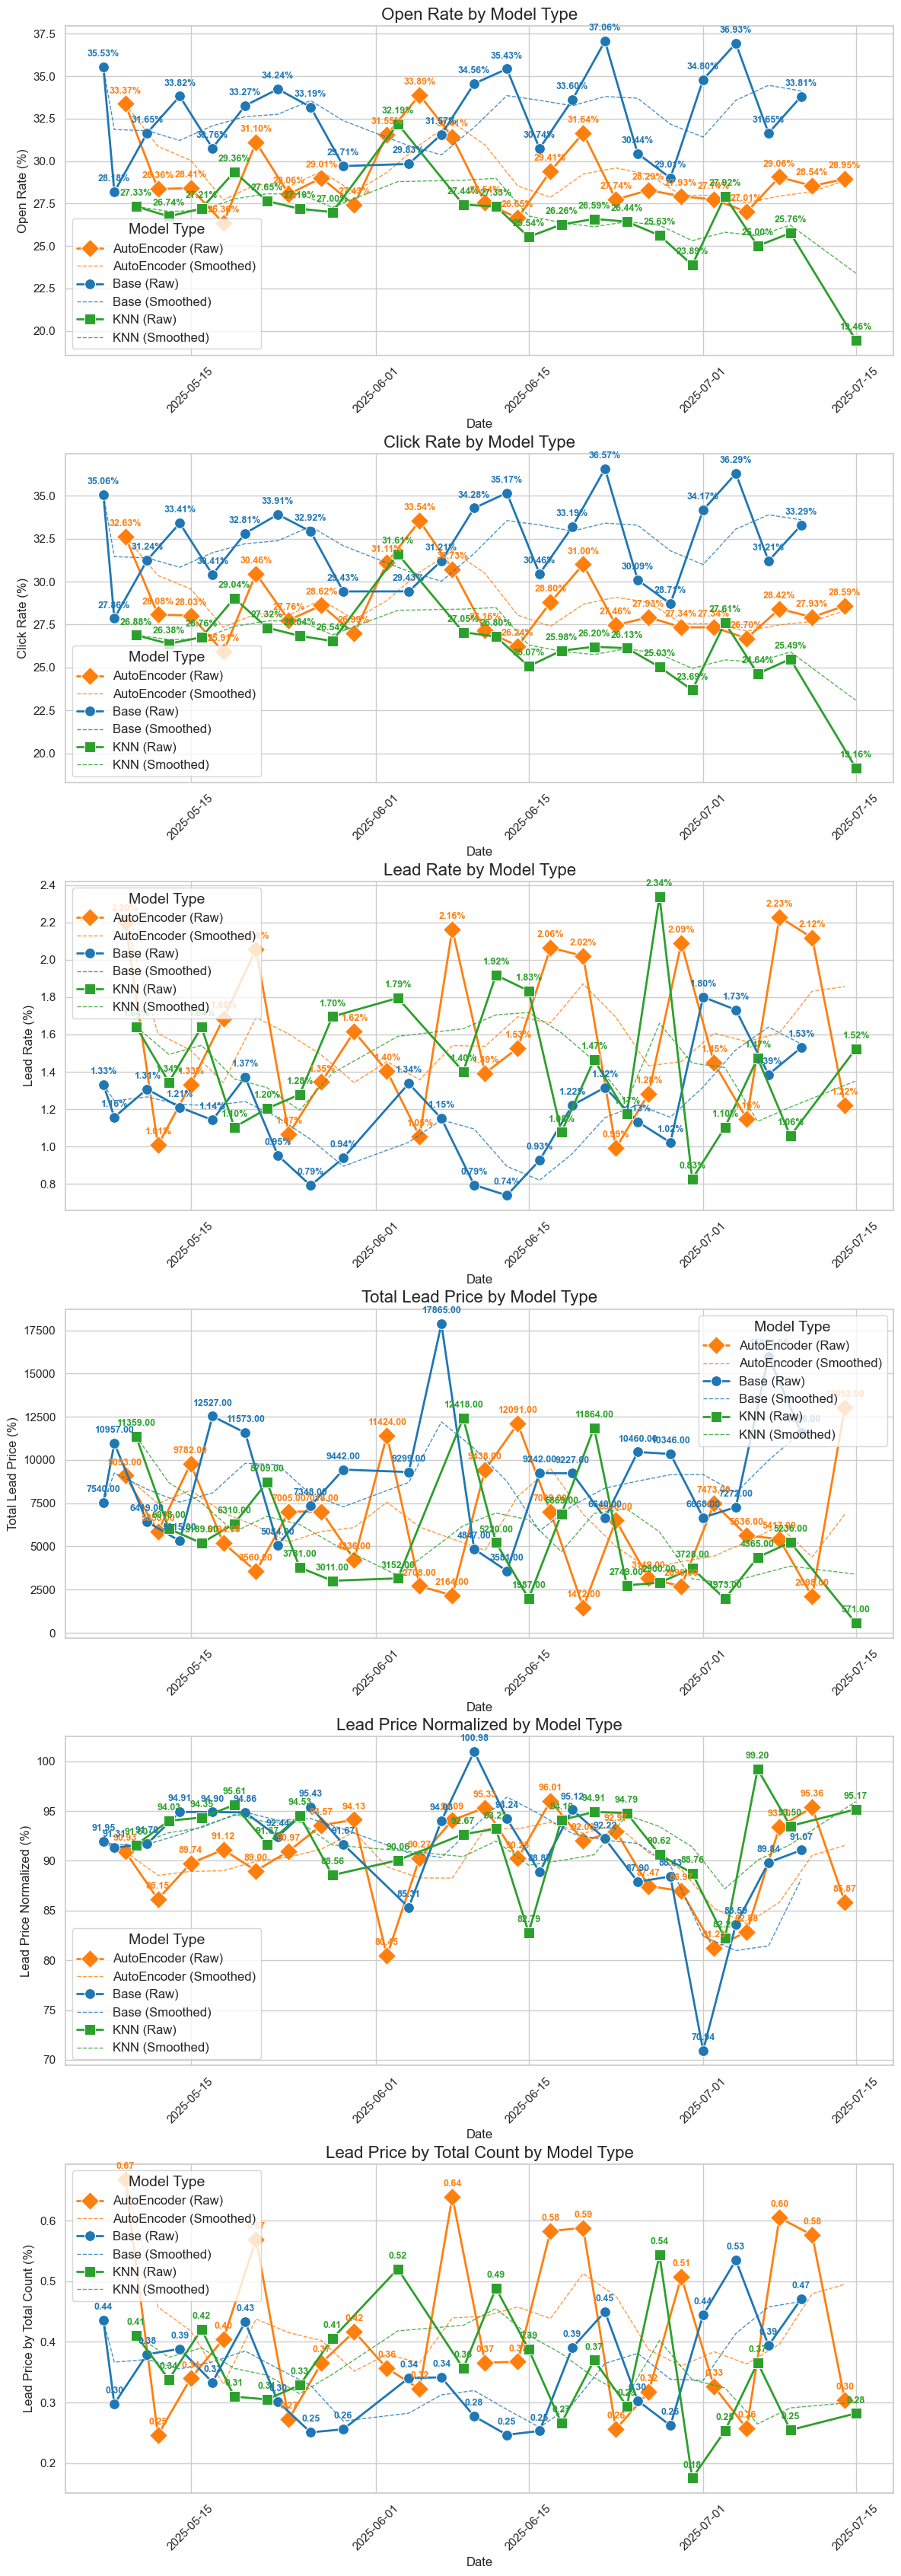

In [12]:
# Plot using the new function with model-based styling
plot_mailing_stats_by_model(mailing_stats_df)

In [13]:
# Display average price per lead by date and model
mailing_stats_df["avg_price_per_lead"] = (mailing_stats_df["leaded_price"] / mailing_stats_df["leaded_cnt"]).fillna(0)

# Show total revenue by model
model_revenue = mailing_stats_df.groupby("model").agg(
    {
        "leaded_cnt": "sum",
        "leaded_price": "sum",
        "avg_price_per_lead": lambda x: (
            sum(x * mailing_stats_df.loc[x.index, "leaded_cnt"]) / sum(mailing_stats_df.loc[x.index, "leaded_cnt"])
            if sum(mailing_stats_df.loc[x.index, "leaded_cnt"]) > 0
            else 0
        ),
    }
)
model_revenue.columns = ["Total Leads", "Total Revenue", "Weighted Avg Price per Lead"]
model_revenue

,Total Leads,Total Revenue,Weighted Avg Price per Lead
model,,,
AutoEncoder,1617,144081,89.103896
Base,2197,199209,90.673191
KNN,1158,107409,92.753886


In [14]:
# Plot daily lead price data by model
def plot_lead_price_stats_by_model(mailing_stats_df: pd.DataFrame) -> None:
    # Set the style for all plots
    sns.set(style="whitegrid")

    # Create a figure with two subplots
    fig, axes = plt.subplots(2, 1, figsize=(12, 14))

    # Colors and markers for each model type
    model_styles = {
        "Base": {"color": "#1f77b4", "marker": "o", "markersize": 10},
        "AutoEncoder": {"color": "#ff7f0e", "marker": "D", "markersize": 12},
        "KNN": {"color": "#2ca02c", "marker": "s", "markersize": 10},
    }

    # Make sure date column is properly datetime type
    if not pd.api.types.is_datetime64_any_dtype(mailing_stats_df["date"]):
        mailing_stats_df = mailing_stats_df.copy()
        mailing_stats_df["date"] = pd.to_datetime(mailing_stats_df["date"])

    # Sort dataframe by date to ensure proper line plotting
    mailing_stats_df = mailing_stats_df.sort_values("date")

    # Plot 1: Total leaded price by date and model
    ax = axes[0]
    for model_name, group_df in mailing_stats_df.groupby("model"):
        style = model_styles[model_name]

        # Plot the line
        sns.lineplot(
            data=group_df,
            x="date",
            y="leaded_price",
            ax=ax,
            marker=style["marker"],
            markersize=style["markersize"],
            color=style["color"],
            linewidth=2.5,
            label=f"{model_name}",
        )

        # Add value annotations
        for _, row in group_df.iterrows():
            if row["leaded_price"] > 0:  # Only annotate days with revenue
                ax.annotate(
                    f"{row['leaded_price']:.0f}",
                    (row["date"], row["leaded_price"]),
                    textcoords="offset points",
                    xytext=(0, 10),
                    ha="center",
                    fontsize=9,
                    fontweight="bold",
                    color=style["color"],
                )

    # Set title and labels
    ax.set_title("Total Lead Revenue by Date and Model", fontsize=16)
    ax.set_xlabel("Date", fontsize=12)
    ax.set_ylabel("Total Lead Revenue", fontsize=12)

    # Format x-axis with dates
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
    plt.setp(ax.get_xticklabels(), rotation=45)

    # Add legend
    ax.legend(title="Model Type", fontsize=12, title_fontsize=14)

    # Plot 2: Average price per lead by date and model
    ax = axes[1]
    for model_name, group_df in mailing_stats_df.groupby("model"):
        # Filter out rows with zero leads to avoid infinity/NaN in avg price
        filtered_df = group_df[group_df["leaded_cnt"] > 0]
        if filtered_df.empty:
            continue

        style = model_styles[model_name]

        # Plot the line
        sns.lineplot(
            data=filtered_df,
            x="date",
            y="avg_price_per_lead",
            ax=ax,
            marker=style["marker"],
            markersize=style["markersize"],
            color=style["color"],
            linewidth=2.5,
            label=f"{model_name}",
        )

        # Add value annotations
        for _, row in filtered_df.iterrows():
            ax.annotate(
                f"{row['avg_price_per_lead']:.2f}",
                (row["date"], row["avg_price_per_lead"]),
                textcoords="offset points",
                xytext=(0, 10),
                ha="center",
                fontsize=9,
                fontweight="bold",
                color=style["color"],
            )

    # Set title and labels
    ax.set_title("Average Price per Lead by Date and Model", fontsize=16)
    ax.set_xlabel("Date", fontsize=12)
    ax.set_ylabel("Avg Price per Lead", fontsize=12)

    # Format x-axis with dates
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
    plt.setp(ax.get_xticklabels(), rotation=45)

    # Add legend
    ax.legend(title="Model Type", fontsize=12, title_fontsize=14)

    # Add model comparison text at the bottom
    plt.figtext(
        0.5,
        0.01,
        f"Model Revenue Comparison:\n{model_revenue.to_string()}",
        ha="center",
        fontsize=12,
        bbox=dict(boxstyle="round,pad=0.5", fc="lightgray", ec="gray", alpha=0.8),
    )

    plt.tight_layout()
    plt.subplots_adjust(bottom=0.15)  # Add space at the bottom for the comparison text
    plt.show()

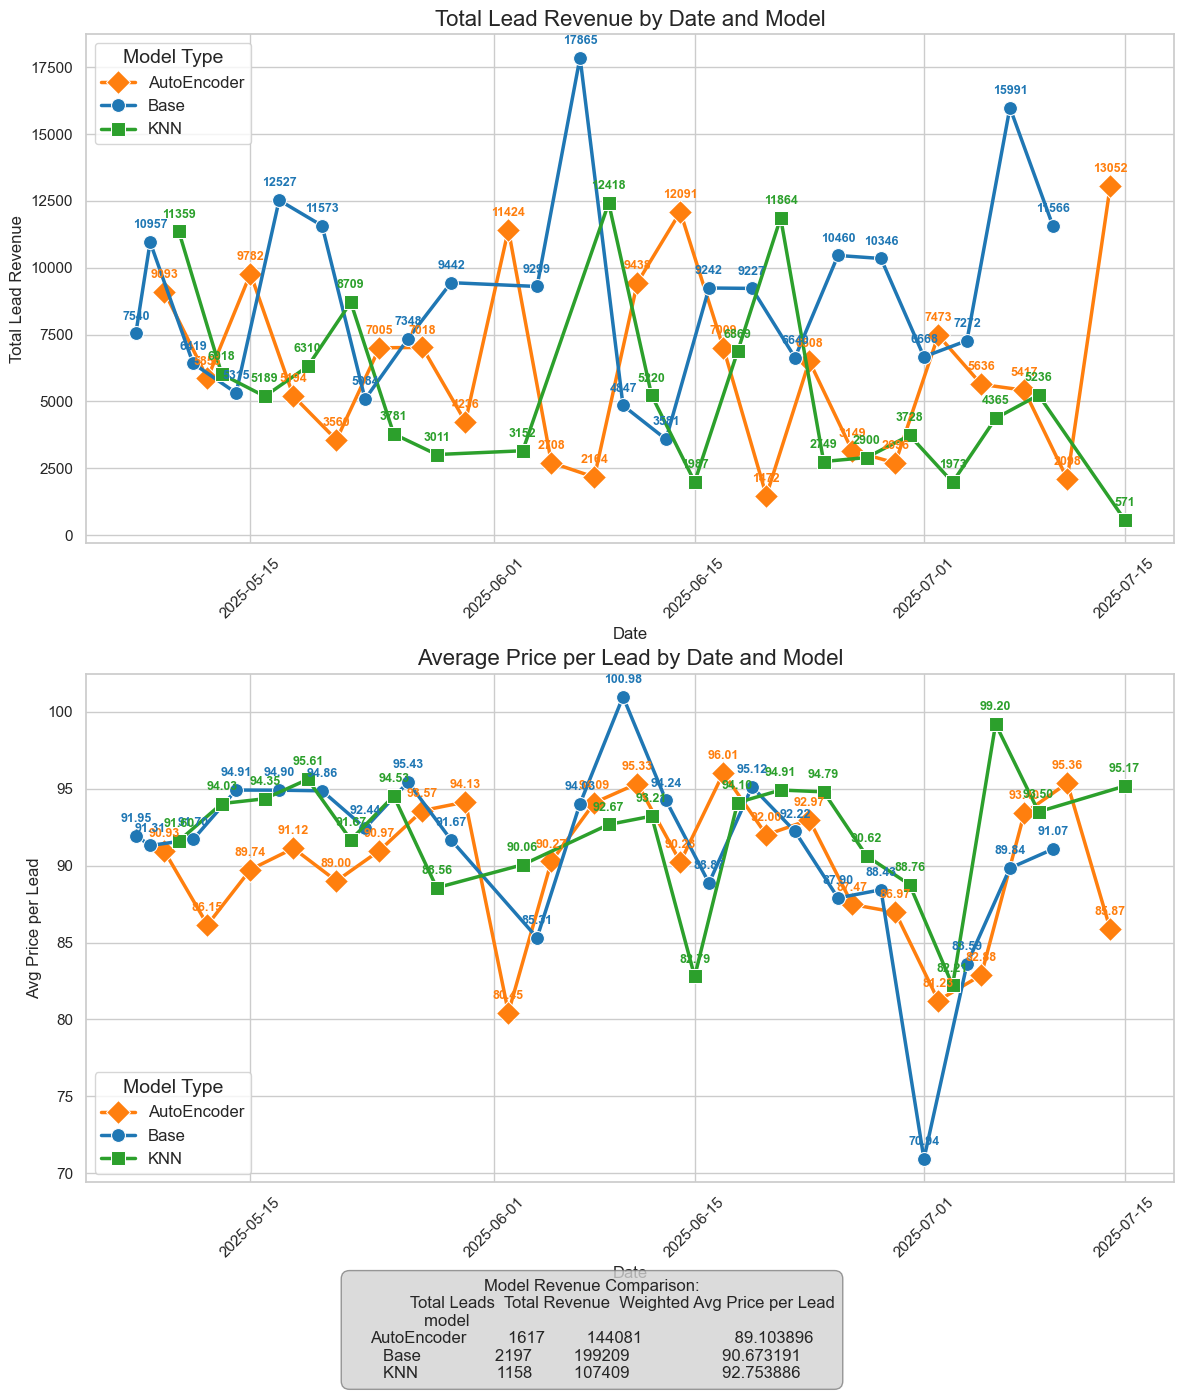

In [15]:
# Plot the lead price data with smoothed trends
plot_lead_price_stats_by_model(mailing_stats_df)

# Scores analysis

In [16]:
# Query to get individual prospect records with scores for histogram analysis
PROSPECTS_SCORES_QUERY = """
select
    p.score,
    p.communication_status,
    date(p.scheduled_at) as date,
    case when p.communication_status = 'leaded' then 1 else 0 end as is_lead
from
    emails_ai.prospect p
left join rds2.offers_budget b on p.offer_id = b.offer_id
left join rds2.offers_budgetperiod bp on
    b.id = bp.budget_id and
    DATE_TRUNC('month', p.scheduled_at) = bp.period
where
    p.scheduled_at >= %s
    and p.scheduled_at < %s
    and bp.settlement = 0
    and p.sg_message_id is not null
    and p.score is not null
"""


async def load_prospects_scores(start_date: str, end_date: str) -> pd.DataFrame:
    prospects_data = await execute_query(PROSPECTS_SCORES_QUERY, (start_date, end_date))
    return pd.DataFrame(prospects_data)

In [17]:
# Load prospects scores data
prospects_df = await load_prospects_scores("2025-05-06", "2025-07-15")

In [18]:
# leave only rows with communication_status in ('open', 'click', 'leaded')
prospects_df = prospects_df[prospects_df["communication_status"].isin(["open", "click", "leaded"])]

In [19]:
# Add model type based on date using the same mapping as before
prospects_df["model"] = prospects_df["date"].apply(lambda x: model_dates.get(x.strftime("%Y-%m-%d"), "Base"))

# Create score bins for better visualization
prospects_df["score_bin"] = pd.cut(prospects_df["score"], bins=50, include_lowest=True)

print(f"Total prospects: {len(prospects_df)}")
print(f"Score range: {prospects_df['score'].min():.3f} - {prospects_df['score'].max():.3f}")
print("Model distribution:")
print(prospects_df["model"].value_counts())
print("\nSample data:")
prospects_df.head()

Total prospects: 394157
Score range: -0.071 - 1.000
Model distribution:
model
Base           187267
AutoEncoder    114297
KNN             92593
Name: count, dtype: int64

Sample data:


,score,communication_status,date,is_lead,model,score_bin
1,0.926629,open,2025-07-08,0,AutoEncoder,"(0.914, 0.936]"
6,0.021540,open,2025-05-08,0,Base,"(0.0144, 0.0359]"
22,0.946096,open,2025-05-24,0,AutoEncoder,"(0.936, 0.957]"
27,0.885781,open,2025-05-18,0,AutoEncoder,"(0.871, 0.893]"
40,0.019445,open,2025-05-17,0,Base,"(0.0144, 0.0359]"


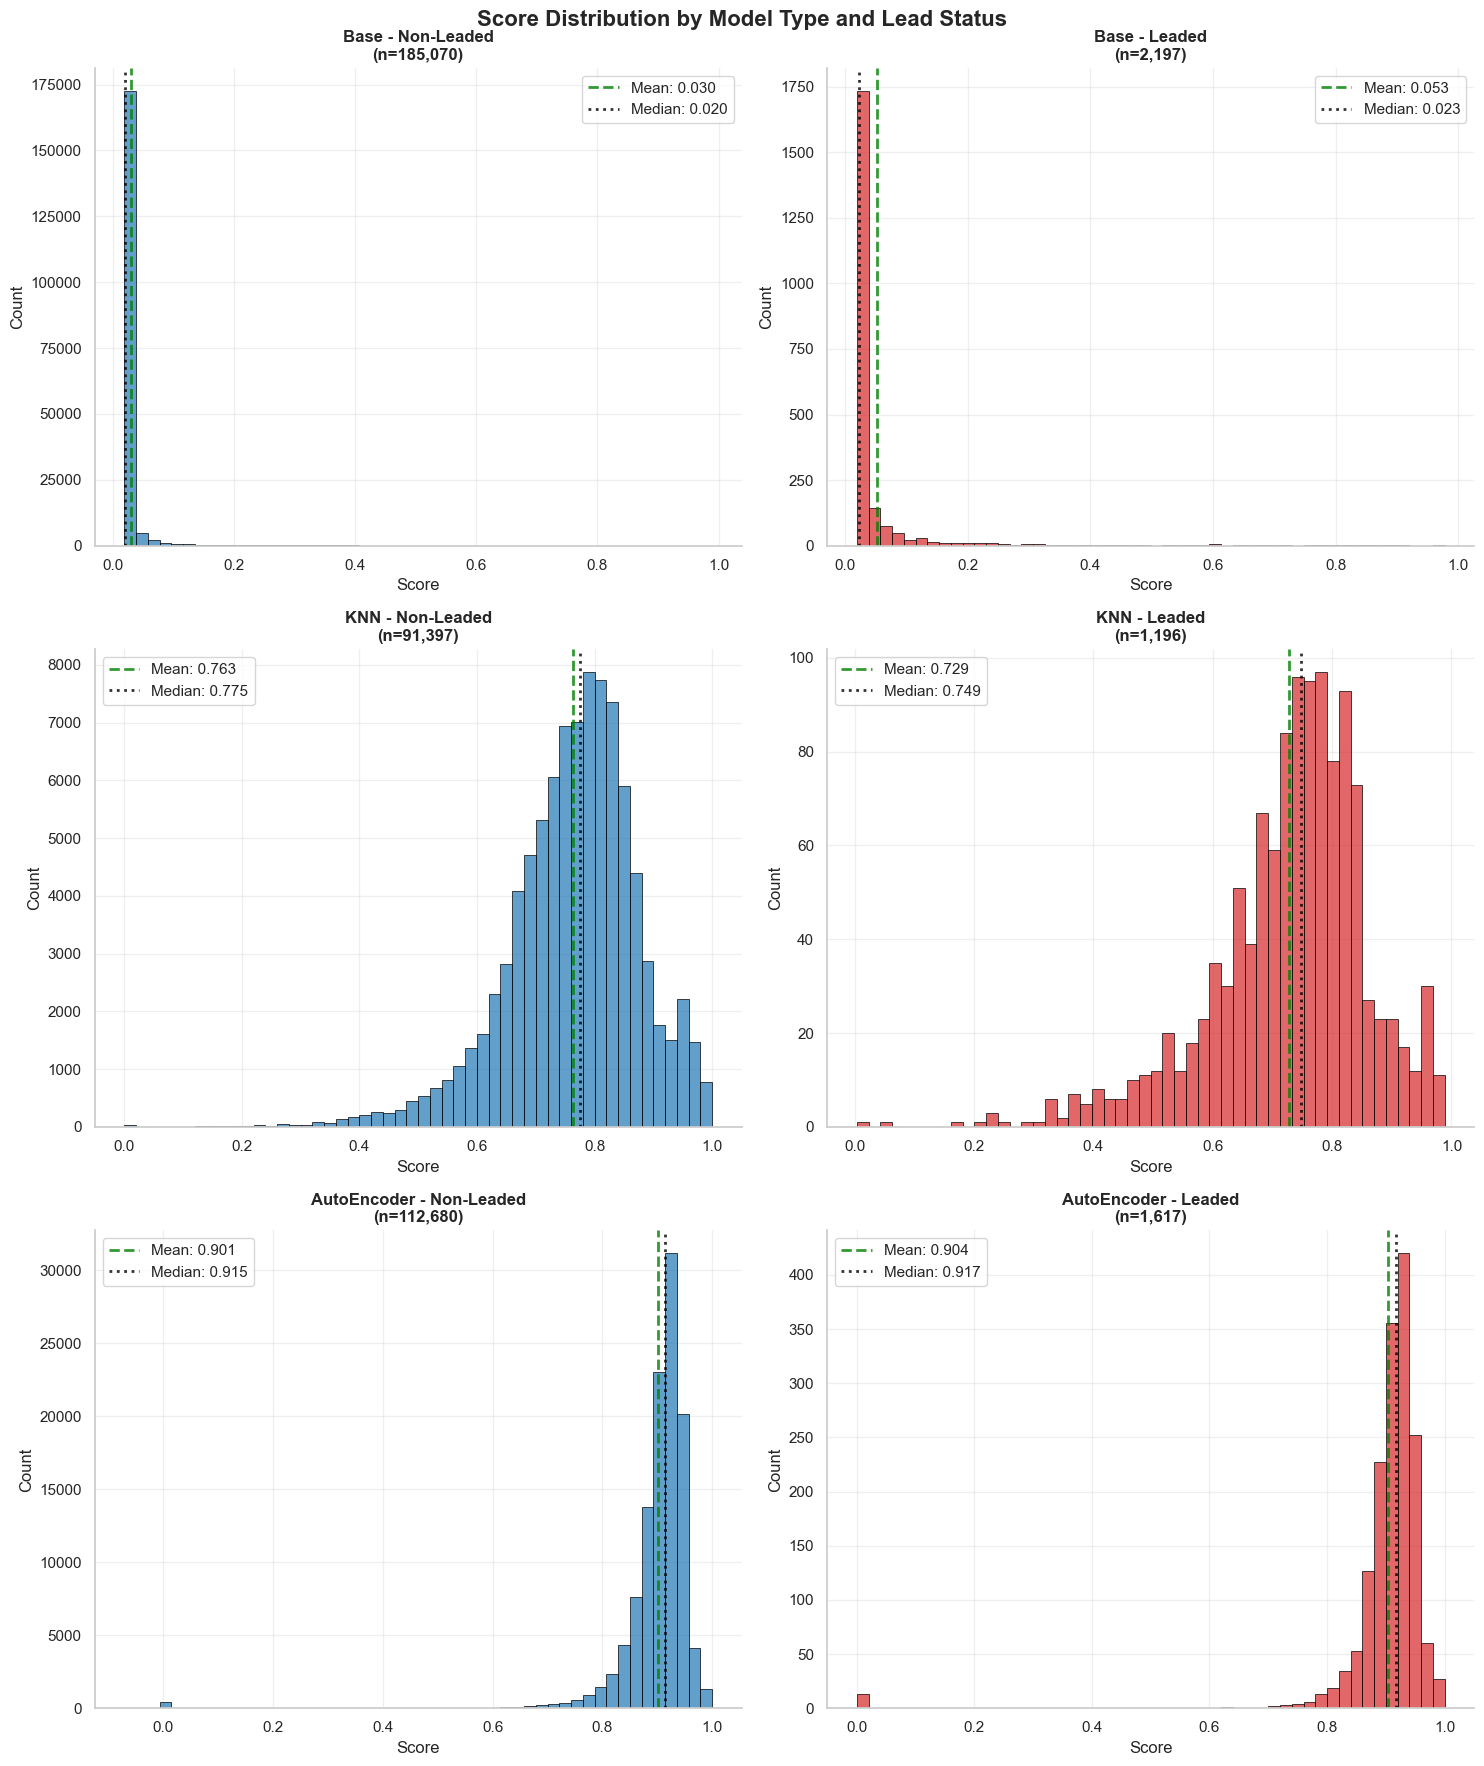

In [20]:
def create_score_histograms_grid(prospects_df: pd.DataFrame, bins: int = 50):
    """
    Create a 3x2 grid of histograms showing score distributions for each model by lead status
    """
    # Set up the plot
    fig, axes = plt.subplots(3, 2, figsize=(15, 18))
    fig.suptitle("Score Distribution by Model Type and Lead Status", fontsize=16, fontweight="bold")

    # Remove spines for all subplots
    sns.despine()

    models = ["Base", "KNN", "AutoEncoder"]
    lead_status = [0, 1]  # 0 = Non-Leaded, 1 = Leaded
    lead_labels = ["Non-Leaded", "Leaded"]
    colors = ["#1f77b4", "#d62728"]  # Blue for non-leaded, Red for leaded

    for i, model in enumerate(models):
        for j, lead in enumerate(lead_status):
            ax = axes[i, j]

            # Filter data for current model and lead status
            model_lead_data = prospects_df[(prospects_df["model"] == model) & (prospects_df["is_lead"] == lead)]

            if len(model_lead_data) == 0:
                ax.set_title(f"{model} - {lead_labels[j]}\n(No data)", fontweight="bold")
                ax.set_xlabel("Score")
                ax.set_ylabel("Count")
                continue

            # Create histogram
            sns.histplot(
                data=model_lead_data,
                x="score",
                bins=bins,
                ax=ax,
                color=colors[j],
                alpha=0.7,
                edgecolor="black",
                linewidth=0.5,
                legend=False,  # Disable seaborn legend to avoid duplication
            )

            # Calculate statistics
            mean_score = model_lead_data["score"].mean()
            median_score = model_lead_data["score"].median()
            count = len(model_lead_data)

            # Add vertical lines for mean and median
            mean_line = ax.axvline(
                mean_score, color="green", linestyle="--", alpha=0.8, linewidth=2, label=f"Mean: {mean_score:.3f}"
            )
            median_line = ax.axvline(
                median_score, color="black", linestyle=":", alpha=0.8, linewidth=2, label=f"Median: {median_score:.3f}"
            )

            # Customize the plot
            ax.set_title(f"{model} - {lead_labels[j]}\n(n={count:,})", fontweight="bold")
            ax.set_xlabel("Score")
            ax.set_ylabel("Count")
            ax.grid(True, alpha=0.3)

            # Create legend only for the mean and median lines by explicitly specifying handles
            ax.legend(handles=[mean_line, median_line])

    plt.tight_layout()
    plt.show()


# Create the grid of histograms
create_score_histograms_grid(prospects_df)